In [ ]:
# One-time kernel bootstrap for this notebook.
%pip install -q numpy matplotlib torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Naive MLP for Battery Surrogate with Pointwise Temperature Prediction
Input: [time, current/input signals, x, y, z] with fixed fluid constants (not concatenated to model input)
Output: [bc_v, T] where T is a single scalar temperature target

In [ ]:
# Import core libraries and set device.
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import csv
from typing import Dict, Optional, Sequence, Tuple
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# Load OP1..OP6 input signals and fluid values.
from load_op_inputs import load_op_input_and_fluid

op_data = load_op_input_and_fluid([1, 2, 3, 4, 5, 6])
print(f"Loaded OP data for OPs: {list(op_data.keys())}")

Loaded OP data for OPs: [1, 2, 3, 4, 5, 6]


In [ ]:
# Split and store input signals and fluid values by OP.
input_signals_by_op = {op_id: op_data[op_id]["input_signals"] for op_id in range(1, 7)}
fluid_values_by_op = {op_id: op_data[op_id]["fluidstoffwerte"] for op_id in range(1, 7)}
input_headers_by_op = {op_id: [h.strip() for h in op_data[op_id]["input_headers"]] for op_id in range(1, 7)}
fluid_headers_by_op = {op_id: [h.strip() for h in op_data[op_id]["fluid_headers"]] for op_id in range(1, 7)}
print(f"Input signals shape per OP: {input_signals_by_op[1].shape}")
print(f"Fluid values shape per OP: {fluid_values_by_op[1].shape}")

Input signals shape per OP: (1, 7)
Fluid values shape per OP: (1, 3)


In [ ]:
# Load coordinate grids from three CSV files (Cell Center, Gehäusewand, JR1 Center).
coord_dir = Path(r"c:\Users\M0245635\batterysurrogatemodell\coordinates")
coord_files = {
    "cell_center": "Coordinates - Grid Cell Center.csv",
    "gehaeusewand": "Coordinates - Grid Gehäusewand.csv",
    "jr1_center": "Coordinates - Grid JR1 Center.csv",
}

coords_by_layer = {}
for layer_name, file_name in coord_files.items():
    file_path = coord_dir / file_name
    data = np.genfromtxt(file_path, delimiter=",", skip_header=1, dtype=float)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    coords_by_layer[layer_name] = data  # shape: (n_points, 3)
    print(f"{layer_name}: {data.shape[0]} grid points")

total_grid_points = sum(c.shape[0] for c in coords_by_layer.values())
print(f"Total grid points across all layers: {total_grid_points}")

cell_center: 121 grid points
gehaeusewand: 121 grid points
jr1_center: 121 grid points
Total grid points across all layers: 363


In [ ]:
# Load FMU data for OP1..OP7 and extract time, bc_v, and temperature columns.
dataset_roots = [
    Path(r"c:\Users\M0245635\Downloads"),
    Path(r"c:\Users\M0245635\Desktop"),
]

def get_op_file(op_id: int, file_name: str) -> Path:
    for root in dataset_roots:
        nested = root / f"OP{op_id}" / f"OP{op_id}" / file_name
        flat = root / f"OP{op_id}" / file_name
        if nested.exists():
            return nested
        if flat.exists():
            return flat
    raise FileNotFoundError(f"Could not find {file_name} for OP{op_id}")

def find_optional_op_file(op_id: int, file_name: str) -> Optional[Path]:
    for root in dataset_roots:
        nested = root / f"OP{op_id}" / f"OP{op_id}" / file_name
        flat = root / f"OP{op_id}" / file_name
        if nested.exists():
            return nested
        if flat.exists():
            return flat
    return None

def load_csv_headers_and_data(file_path: Path) -> Tuple[list, np.ndarray]:
    with file_path.open("r", encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f)
        headers = next(reader)
    data = np.genfromtxt(file_path, delimiter=",", skip_header=1, dtype=float)
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return headers, data

fmu_data = {}
for op_id in range(1, 8):
    fmu_file = get_op_file(op_id, f"OP{op_id}_Batemo FMU1.csv")
    headers, data = load_csv_headers_and_data(fmu_file)

    # Some datasets store temperatures in a separate OP*_Temperaturen.csv file.
    temp_file = find_optional_op_file(op_id, f"OP{op_id}_Temperaturen.csv")
    temp_headers, temp_data = (None, None)
    if temp_file is not None:
        temp_headers, temp_data = load_csv_headers_and_data(temp_file)

    fmu_data[op_id] = {
        "headers": headers,
        "data": data,
        "temp_headers": temp_headers,
        "temp_data": temp_data,
    }
    temp_cols = 0 if temp_headers is None else max(0, len(temp_headers) - 1)
    print(f"OP{op_id}: {data.shape[0]} time steps, {data.shape[1]} FMU cols, {temp_cols} temp cols")

OP1: 14450 time steps, 10 FMU cols, 13 temp cols
OP2: 14309 time steps, 10 FMU cols, 13 temp cols
OP3: 14558 time steps, 10 FMU cols, 13 temp cols
OP4: 14450 time steps, 11 FMU cols, 13 temp cols
OP5: 14736 time steps, 11 FMU cols, 13 temp cols
OP6: 14450 time steps, 11 FMU cols, 13 temp cols
OP7: 14193 time steps, 11 FMU cols, 13 temp cols


In [ ]:
# Build OP1 pilot tensors and normalization stats (single-temperature target per sample).
OP_PILOT = 1


def _norm_name(name: str) -> str:
    return name.strip().lower()


def _find_first(headers, include_terms, exclude_terms=()):
    for i, h in enumerate(headers):
        hh = _norm_name(h)
        if any(term in hh for term in include_terms) and not any(term in hh for term in exclude_terms):
            return i
    return None


def _find_all(headers, include_terms, exclude_terms=()):
    out = []
    for i, h in enumerate(headers):
        hh = _norm_name(h)
        if any(term in hh for term in include_terms) and not any(term in hh for term in exclude_terms):
            out.append(i)
    return out


def fit_standard_stats(x: np.ndarray, eps: float = 1e-8):
    mean = x.mean(axis=0, keepdims=True)
    std = x.std(axis=0, keepdims=True)
    std = np.where(std < eps, 1.0, std)
    return mean, std


def apply_standardize(x: np.ndarray, mean: np.ndarray, std: np.ndarray):
    return (x - mean) / std


headers = fmu_data[OP_PILOT]["headers"]
data = fmu_data[OP_PILOT]["data"]

# Robustly detect time and bc_v in FMU. Temperature can be in FMU or OP*_Temperaturen.csv.
time_idx = _find_first(headers, include_terms=["time", "zeit"])
bc_v_idx = _find_first(headers, include_terms=["bc_v", "bc v", "terminal voltage", "voltage", "klemmen"], exclude_terms=["ocv"])
T_idx = _find_all(
    headers,
    include_terms=["temperature", "temperatur", "temp", " t_", "t_", "_t", " tavg", "tavg", "tmax", "tmin"],
    exclude_terms=["ambient", "coolant"],
)

if time_idx is None:
    raise ValueError("Could not detect time column in FMU headers. Please inspect headers manually.")
if bc_v_idx is None:
    raise ValueError("Could not detect bc_v/terminal voltage column in FMU headers. Please inspect headers manually.")

time_s = data[:, [time_idx]].astype(np.float32)
bc_v = data[:, [bc_v_idx]].astype(np.float32)

# Primary source: temperature columns found in FMU1 file.
if len(T_idx) > 0:
    T_grid = data[:, T_idx].astype(np.float32)
    temp_feature_names = [headers[i] for i in T_idx]
    temp_source = "FMU"
else:
    # Fallback: use OP*_Temperaturen.csv when FMU does not contain temperature channels.
    temp_headers = fmu_data[OP_PILOT].get("temp_headers")
    temp_data = fmu_data[OP_PILOT].get("temp_data")
    if temp_headers is None or temp_data is None or temp_data.shape[1] < 2:
        raise ValueError(
            "Could not detect any temperature columns in FMU headers and OP*_Temperaturen.csv is missing/invalid."
        )

    temp_time_idx = _find_first(temp_headers, include_terms=["time", "zeit"])
    if temp_time_idx is None:
        temp_time_idx = 0

    temp_idx_all = [i for i in range(temp_data.shape[1]) if i != temp_time_idx]
    if len(temp_idx_all) == 0:
        raise ValueError("OP*_Temperaturen.csv does not contain usable temperature columns.")

    T_grid = temp_data[:, temp_idx_all].astype(np.float32)
    temp_feature_names = [temp_headers[i] for i in temp_idx_all]
    temp_source = "OP*_Temperaturen.csv"

# Single-temperature target mode: choose one physical temperature channel.
temperature_target_col = 0
if T_grid.shape[1] == 0:
    raise ValueError("No temperature channels available to build a scalar target.")
if not (0 <= temperature_target_col < T_grid.shape[1]):
    raise ValueError(f"temperature_target_col={temperature_target_col} is out of range [0, {T_grid.shape[1]-1}]")
T_scalar = T_grid[:, [temperature_target_col]].astype(np.float32)
T_scalar_name = temp_feature_names[temperature_target_col]

input_signals = input_signals_by_op[OP_PILOT].astype(np.float32)
fluid_values = fluid_values_by_op[OP_PILOT].astype(np.float32)

# Fluid values are static (or near-static). Keep one row for schema; tile later if needed.
if fluid_values.ndim == 1:
    fluid_values = fluid_values.reshape(1, -1)

xyz = np.vstack(list(coords_by_layer.values())).astype(np.float32)

norm_stats = {
    "time": fit_standard_stats(time_s),
    "input_signals": fit_standard_stats(input_signals),
    "fluid_values": fit_standard_stats(fluid_values),
    "xyz": fit_standard_stats(xyz),
    "bc_v": fit_standard_stats(bc_v),
    "T_grid": fit_standard_stats(T_grid),
    "T_scalar": fit_standard_stats(T_scalar),
}

op1_raw = {
    "time": time_s,
    "input_signals": input_signals,
    "fluid_values": fluid_values,
    "xyz": xyz,
    "bc_v": bc_v,
    "T_grid": T_grid,
    "T_scalar": T_scalar,
}

op1_norm = {
    name: apply_standardize(arr, *norm_stats[name])
    for name, arr in op1_raw.items()
}

print(f"Detected time column: {headers[time_idx]}")
print(f"Detected bc_v column: {headers[bc_v_idx]}")
print(f"Temperature source: {temp_source}")
print(f"Detected temperature columns: {T_grid.shape[1]}")
print(f"Using scalar temperature target column: {temperature_target_col} -> {T_scalar_name}")
print(
    f"Shapes | time={time_s.shape}, input={input_signals.shape}, fluid={fluid_values.shape}, "
    f"xyz={xyz.shape}, bc_v={bc_v.shape}, T_grid={T_grid.shape}, T_scalar={T_scalar.shape}"
)

Detected time column: Physical Time (s)
Detected bc_v column: bc_V Monitor
Temperature source: OP*_Temperaturen.csv
Detected temperature columns: 13
Using scalar temperature target column: 0 -> T_ntc Monitor (C)
Shapes | time=(14450, 1), input=(1, 7), fluid=(1, 3), xyz=(363, 3), bc_v=(14450, 1), T_grid=(14450, 13), T_scalar=(14450, 1)


In [ ]:
# Configurable MLP definition cell (documented)
"""
What this cell gives you:
1) Easy hyperparameter controls (hidden layers, neurons/layer, Swish beta).
2) A Swish(beta) activation with user-selected beta.
3) Linear last layer (no output activation).
4) Explicit input convention for this notebook:
   - Model dynamic input = [t, input_signals, x, y, z]
   - fluid_values are NOT model inputs here; they are treated as fixed constants
     that you can provide separately (e.g., for logging, conditioning outside the MLP,
     or future feature extensions).
5) Output convention in this version: [bc_v, T_scalar] (single temperature target).
"""

# -----------------------------
# 1) Hyperparameters (edit me)
# -----------------------------
mlp_hparams = {
    "num_hidden_layers": 4,        # You choose: number of hidden layers
    "neurons_per_hidden": 128,     # You choose: width of each hidden layer
    "swish_beta": 1.0,             # You choose: beta in Swish(x) = x * sigmoid(beta*x)
    "dtype": torch.float32,
}

# Fixed fluid constants placeholder (you said you will provide these).
# Expected shape: (1, n_fluid_features) or (n_fluid_features,)
fixed_fluid_values = None


class SwishBeta(nn.Module):
    """Swish activation with user-controlled beta: x * sigmoid(beta * x)."""
    def __init__(self, beta: float = 1.0):
        super().__init__()
        self.beta = float(beta)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * torch.sigmoid(self.beta * x)


class NaiveBatteryMLP(nn.Module):
    """
    Naive MLP with:
    - configurable hidden depth and width
    - Swish(beta) in hidden layers
    - linear output layer
    """
    def __init__(self, in_dim: int, out_dim: int, num_hidden_layers: int, neurons_per_hidden: int, swish_beta: float):
        super().__init__()
        if num_hidden_layers < 1:
            raise ValueError("num_hidden_layers must be >= 1")
        if neurons_per_hidden < 1:
            raise ValueError("neurons_per_hidden must be >= 1")

        layers = []
        prev = in_dim
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(prev, neurons_per_hidden))
            layers.append(SwishBeta(beta=swish_beta))
            prev = neurons_per_hidden

        # Last layer is linear by design (no activation appended).
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def build_dynamic_input_tensor(
    t: np.ndarray,
    input_sig: np.ndarray,
    xyz_arr: np.ndarray,
    t_index: int = 0,
    dtype: torch.dtype = torch.float32,
    device_: torch.device = device,
    norm_stats_: Optional[Dict[str, Tuple[np.ndarray, np.ndarray]]] = None,
    use_normalized: bool = True,
    fluid_fixed_values: Optional[np.ndarray] = None,
    ):
    """
    Build model input using ONLY dynamic terms: [t, input_signals, xyz].
    fluid_fixed_values is accepted for bookkeeping/confirmation but not concatenated.
    """
    t_row = t[[t_index]]  # shape (1,1)
    sig_row = input_sig[[t_index]]  # shape (1,n_sig)

    # Tile time and signal row across all spatial points for this time index.
    t_tile = np.repeat(t_row, xyz_arr.shape[0], axis=0)
    sig_tile = np.repeat(sig_row, xyz_arr.shape[0], axis=0)

    x_np = np.concatenate([t_tile, sig_tile, xyz_arr], axis=1).astype(np.float32)

    if use_normalized and norm_stats_ is not None:
        t_n = apply_standardize(t_tile, *norm_stats_["time"])
        sig_n = apply_standardize(sig_tile, *norm_stats_["input_signals"])
        xyz_n = apply_standardize(xyz_arr, *norm_stats_["xyz"])
        x_np = np.concatenate([t_n, sig_n, xyz_n], axis=1).astype(np.float32)

    x_t = torch.tensor(x_np, dtype=dtype, device=device_)

    if fluid_fixed_values is not None:
        f = np.asarray(fluid_fixed_values)
        if f.ndim == 1:
            f = f.reshape(1, -1)
    else:
        f = None

    return x_t, f


# Infer dimensions from currently loaded OP1 data.
in_dim = 1 + op1_raw["input_signals"].shape[1] + op1_raw["xyz"].shape[1]  # [t, input_signals, xyz]
out_dim = op1_raw["bc_v"].shape[1] + op1_raw["T_scalar"].shape[1]         # [bc_v, T_scalar]

model = NaiveBatteryMLP(
    in_dim=in_dim,
    out_dim=out_dim,
    num_hidden_layers=mlp_hparams["num_hidden_layers"],
    neurons_per_hidden=mlp_hparams["neurons_per_hidden"],
    swish_beta=mlp_hparams["swish_beta"],
).to(device=device, dtype=mlp_hparams["dtype"])

print("MLP configured successfully.")
print(f"Input to model uses: [t, input_signals, xyz] -> in_dim = {in_dim}")
print("fluid_values are excluded from model input and treated as fixed constants provided separately.")
print(f"Output is linear with out_dim = {out_dim} (bc_v + T_scalar)")
print(f"Hyperparams: {mlp_hparams}")

MLP configured successfully.
Input to model uses: [t, input_signals, xyz] -> in_dim = 11
fluid_values are excluded from model input and treated as fixed constants provided separately.
Output is linear with out_dim = 2 (bc_v + T_scalar)
Hyperparams: {'num_hidden_layers': 4, 'neurons_per_hidden': 128, 'swish_beta': 1.0, 'dtype': torch.float32}


Fixed fluid constants (one line per value):
01. Conductivity Monitor (W/m-K): 0.40012732
02. Density Monitor (kg/m^3): 1071.6357
03. Specific Inlet Monitor (J/kg-K): 3374.0857

Architecture summary:
Input(11) -> Hidden1(128, Swish(beta=1.0)) -> Hidden2(128, Swish(beta=1.0)) -> Hidden3(128, Swish(beta=1.0)) -> Hidden4(128, Swish(beta=1.0)) -> Output(2, Linear)


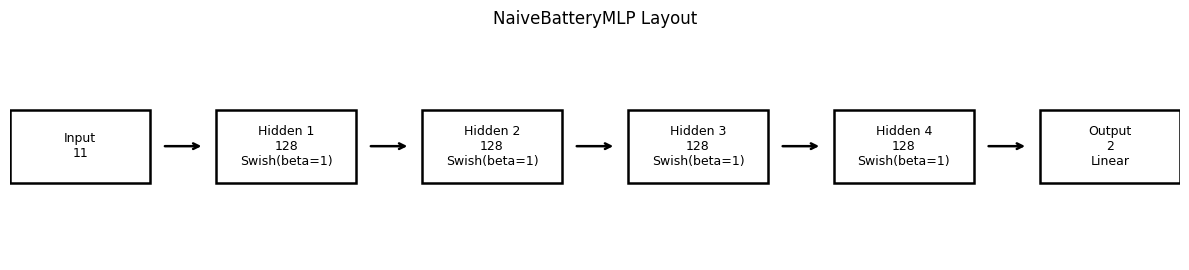

In [ ]:
# Fluid constants (one line per value) + architecture picture
"""
This cell does two things:
1) Prints every fluid value on its own line with the corresponding header name.
2) Draws a simple picture of the current MLP architecture.
"""

# Use OP_PILOT fluid values as default fixed constants if not provided yet.
if fixed_fluid_values is None:
    fixed_fluid_values = op1_raw["fluid_values"][0].copy()

fluid_headers = fluid_headers_by_op[OP_PILOT]
fluid_vec = np.asarray(fixed_fluid_values, dtype=np.float32).reshape(-1)

if len(fluid_headers) != fluid_vec.shape[0]:
    raise ValueError(
        f"Fluid header/value mismatch: headers={len(fluid_headers)}, values={fluid_vec.shape[0]}"
    )

print("Fixed fluid constants (one line per value):")
for idx, (name, val) in enumerate(zip(fluid_headers, fluid_vec), start=1):
    print(f"{idx:02d}. {name}: {val:.8g}")

# Human-readable architecture summary.
hidden_layers = int(mlp_hparams["num_hidden_layers"])
hidden_width = int(mlp_hparams["neurons_per_hidden"])
swish_beta = float(mlp_hparams["swish_beta"])
print()
print("Architecture summary:")
print(f"Input({in_dim}) -> " + " -> ".join([f"Hidden{j+1}({hidden_width}, Swish(beta={swish_beta}))" for j in range(hidden_layers)]) + f" -> Output({out_dim}, Linear)")

# Draw a small architecture picture.
fig, ax = plt.subplots(figsize=(12, 2.8))
ax.axis("off")

labels = [f"Input\n{in_dim}"] + [f"Hidden {i+1}\n{hidden_width}\nSwish(beta={swish_beta:g})" for i in range(hidden_layers)] + [f"Output\n{out_dim}\nLinear"]
x_positions = np.linspace(0.06, 0.94, len(labels))
y = 0.5

for i, (x, label) in enumerate(zip(x_positions, labels)):
    box = plt.Rectangle((x - 0.06, y - 0.16), 0.12, 0.32, fill=False, linewidth=1.8)
    ax.add_patch(box)   
    ax.text(x, y, label, ha="center", va="center", fontsize=9)
    if i < len(labels) - 1:
        ax.annotate("", xy=(x_positions[i + 1] - 0.07, y), xytext=(x + 0.07, y), arrowprops=dict(arrowstyle="->", linewidth=1.8))

plt.title("NaiveBatteryMLP Layout", fontsize=12)
plt.tight_layout()
plt.show()